# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Projection:** Use your calibrated intrinsics to render wireframe 3D shapes (cylinders, cubes, spheres, etc.) overlaid
  onto a real image with correct perspective.
* **Extrinsic calibration:** Given known object dimensions, compute the 3D pose (position + orientation) between an object
   and the camera, and verify by overlaying a wireframe.
* **Vanishing points in the wild:** Apply the calibration techniques from this notebook to your own photos — estimate
  focal lengths, or use vanishing points to measure real-world distances from a single photograph.

For more detailed instructions, please see the [Project 2 Guidelines](https://docs.google.com/document/d/1_w5RefFChBW3IdvhiCvtLgPGkIDNeWNKhVrLjKPL2Fw/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: https://www.youtube.com/watch?v=2HfIU5lp-0I In the video, titled “Find The Horizon Line & Vanishing Points On ANY Image” Dan, explains what the horizon line and the vanishing points are when drawing a portray and how they should be used for a portrayal to be accurate. This provides a more clear intuition on this concepts.
* Source 2: https://www.youtube.com/watch?v=ffvojZONF_A Ihe video, titled “The Cross Ratio”, professor Federico Ardila from San Francisco State University, takes us through the steps to compute the distance between goal and play based on the picture of a soccer game using the cross ratio. It brings clarity to the steps of the process.
* Source 3: https://www.mathworks.com/help/vision/ug/camera-calibration.html This article from the MATLAB help center, talks about camera calibration, particularly given extrinsic parameters which will be useful for this project.
* Source 4: https://www.youtube.com/watch?v=atPLxuaU9-g In the context of single-view metrology, the lecture in the video provides a formula for determining the height based on reference points and the vanishing lines.
* Source 5: https://visionbook.mit.edu/3d_scene_understanding_single_view.html The article from MIT, provides a series of more simplified formulas to identify elements such as the horizon line, focus point and provides picture examples for all of this.

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


# What is Messi's height?
### In this note notebook I will derive his height (cm) from a picture using as reference the known height of a goal post.

In [1]:

import os

repo_path = 'CS131_release'
if not os.path.exists(repo_path):
    !git clone https://github.com/MauricioAlvarez-21/CS131_release.git
os.chdir(os.path.join(repo_path, 'spring_2026', 'project2_release', 'option_A'))

Cloning into 'CS131_release'...
remote: Enumerating objects: 3021, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 3021 (delta 34), reused 2 (delta 2), pack-reused 2973 (from 3)
Receiving objects: 100% (3021/3021), 197.81 MiB | 16.61 MiB/s, done.
Resolving deltas: 100% (1050/1050), done.


I started by reusing HW2.A code to gather:
* Points 0 & 1 and Points 2 & 3 which describe two oparallel lines on the ground
* Points 4 & 5 which describe the height of the goal post (which we know is 244 cm)
* Points 6 & 7 which desbribe Messi's height

Image is 1920 x 1080


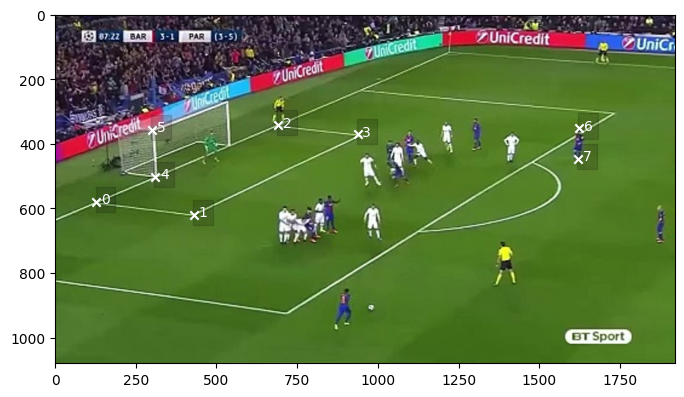

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from typing import Tuple
# Load image and annotated points; note that:
# > Our image is a PIL image type; you can convert this to NumPy with `np.asarray(img)`
# > Points are in (x, y) format, which corresponds to (col, row)!
img = Image.open("neymar.jpeg")
print(f"Image is {img.width} x {img.height}")
points = np.array(
    [
        [128.0, 580.0],  # [0]
        [430.0, 620.0],  # [1]
        [690.0, 342.0],  # [2]
        [937.0, 370.0],  # [3]
        [310.0, 502.0],  # [4]
        [300.0, 356.0],  # [5]
        [1623.0, 352.0],  # [6]
        [1620.0, 447.0],  # [7]
    ]
)

# Visualize image & annotated points
fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(img)
ax.scatter(points[:, 0], points[:, 1], color="white", marker="x")
for i in range(len(points)):
    ax.annotate(
        f"{i}",
        points[i] + np.array([15.0, 5.0]),
        color="white",
        backgroundcolor=(0, 0, 0, 0.15),
        zorder=0.1,
    )

Next, I reused code I produced in HW2.A, to define a function that finds interception between 2 lines given. 2 points on each.

In [3]:
def intersection_from_lines(
    a_0: np.ndarray, a_1: np.ndarray, b_0: np.ndarray, b_1: np.ndarray
) -> np.ndarray:
    """Find the intersection of two lines (infinite length), each defined by a
    pair of points.

    Args:
        a_0 (np.ndarray): First point of first line; shape `(2,)`.
        a_1 (np.ndarray): Second point of first line; shape `(2,)`.
        b_0 (np.ndarray): First point of second line; shape `(2,)`.
        b_1 (np.ndarray): Second point of second line; shape `(2,)`.

    Returns:
        np.ndarray:
    """
    # Validate inputs
    assert a_0.shape == a_1.shape == b_0.shape == b_1.shape == (2,)
    assert a_0.dtype == a_1.dtype == b_0.dtype == b_1.dtype == float

    # Intersection point between lines
    out = np.zeros(2)

    # YOUR CODE HERE
    # We will solve the system of equations using Cramer's Rule

    # We first obtain line A coefficients such that xA x + yA y = cA
    xA = a_0[1] - a_1[1]
    yA = a_1[0] - a_0[0]
    cA = xA * a_0[0] + yA * a_0[1]
    # Now, Line B coefficients such that xB x + yB y = cB
    xB = b_0[1] - b_1[1]
    yB = b_1[0] - b_0[0]
    cB = xB * b_0[0] + yB * b_0[1]
    # Compute determinant
    det = xA * yB - xB * yA
    # Cramer's Rule
    x = (cA * yB - cB * yA) / det
    y = (xA * cB - xB * cA) / det

    out = np.array([x, y])

    # END YOUR CODE

    assert out.shape == (2,)
    assert out.dtype == float

    return out

We first ind the horizon by looking at two parallel lines in the ground and finding where they intercept (vanishing point).

In [10]:
horizon_x, horizon_y = intersection_from_lines(
    points[1], points[0], points[3], points[2])
print("Horizon:", horizon_x, horizon_y )

Horizon: -15676.525280898877 -1513.314606741573


Next, we defined some variables as well as the known goal height

In [5]:
base_goal = points[4]
top_goal = points[5]
goal_height = 244.0 # cm
base_messi = points[7]
top_messi = points[6]


Now, to find Messi's height we will use a process roughly based on the one described in  https://visionbook.mit.edu/3d_scene_understanding_single_view.html

In [9]:
def estimate_height(base_messi, top_messi, base_goal, top_goal, goal_height, horizon_y):

    # We first find the intersection of the line connecting  base of messi and base of the goal and  the horizon line.
    v =intersection_from_lines(base_messi, base_goal, np.array([0, horizon_y]), np.array([1000, horizon_y]))

    # v, can be understood as the horizon point. Now, we find the intercept connecting the horizon point and the top of the goal, and the line describing the height of messi
    r = intersection_from_lines(v, top_goal, base_messi, top_messi)

    # Formula based on Cross-Ratio
    messi_height = goal_height * ((abs(top_messi[1]-base_messi[1]) * abs(v[1]-r[1]))/(abs(r[1]-base_messi[1]) * abs(v[1]-top_messi[1])))
    return messi_height

messi_height = estimate_height(base_messi, top_messi, base_goal, top_goal, goal_height, horizon_y)
print("Messi height: ", messi_height)

Messi height:  158.4410114315173


## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

  The goal of this project is to use the concept of vanishing points to try to calculate the world height of an object when only provided the camera frame. The process shown above is closely related to the concept of Cross-Ratio, which is a geometrical projection technique from 2D to 3D that ignores camera calibration, therefore has a certain margin of error. I started by finding an image that shows Messi on the field along with the goal post and goal box noting clear parallel lines on the ground. Next, I manually traced points on those lines, and assigned them to their respective variables.

  I approximated the horizon line by intercepting two parallel lines on the ground. Once I had all this information, I followed the referenced method , calculating the interception  between bases of target and reference and the horizon line (v) and the interception between point v, the top of the goal, and the height of messi. Once I computed all these variables I was ready to apply the Cross-Ratio formula and estimate Messi’s height.
  
  Given Mess’s true height is 170 cm and he is hunched and with a bended knee in the picture (~165 cm), the error rate of this method is around ~4.14% (165/158.44) which is a margin that we can attribute to the manually assignment of points in the picture and the lack of camera calibration.
